<a href="https://colab.research.google.com/github/malik-abid2442/Prime-AI-and-ML/blob/main/Deep%20Learning/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [6]:
import os

dataset_path = "/kaggle/input/celeba-dataset"

print(os.listdir(dataset_path))

['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [9]:
import os
import shutil

dst = "/content/img_align_celeba"

# Remove if exists
if os.path.exists(dst):
    shutil.rmtree(dst)

# Create symlink again
os.symlink("/kaggle/input/celeba-dataset/versions/2/img_align_celeba", dst)

print("Symlink created!")

FileExistsError: [Errno 17] File exists: '/kaggle/input/celeba-dataset/versions/2/img_align_celeba' -> '/content/img_align_celeba'

In [10]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [11]:
# images load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [16]:


root_dir_path = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [17]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [18]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Generator Network

In [19]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [20]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels),
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64)
        return img

        # fake img => 64 x 64 x 3 x batch_size

# **Discriminator** **Network**

In [21]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D

            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid() # probability of being real/fake
        )

    def forward(self, img):
        return self.model(img)

In [22]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [23]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cuda


In [24]:
generator = generator.to(device)
discriminator = discriminator.to(device)

# Train The GAN

In [25]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device)

In [26]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/5... batch: 1... G-loss:0.7282286882400513.... D-loss: 0.6968917846679688
for epoch: 1/5... batch: 51... G-loss:1.0416607856750488.... D-loss: 0.30232226848602295
for epoch: 1/5... batch: 101... G-loss:2.2237892150878906.... D-loss: 0.1308022439479828
for epoch: 1/5... batch: 151... G-loss:2.6630618572235107.... D-loss: 0.08247017860412598
for epoch: 1/5... batch: 201... G-loss:1.193354606628418.... D-loss: 0.07965995371341705
for epoch: 1/5... batch: 251... G-loss:3.50648832321167.... D-loss: 0.022621335461735725
for epoch: 1/5... batch: 301... G-loss:3.381716728210449.... D-loss: 0.14055225253105164
for epoch: 1/5... batch: 351... G-loss:3.5264317989349365.... D-loss: 0.02362779900431633
for epoch: 1/5... batch: 401... G-loss:4.825997352600098.... D-loss: 0.045709747821092606
for epoch: 1/5... batch: 451... G-loss:3.513233184814453.... D-loss: 0.3691491484642029
for epoch: 1/5... batch: 501... G-loss:2.4213578701019287.... D-loss: 0.1502150297164917
for epoch: 1/5... bat

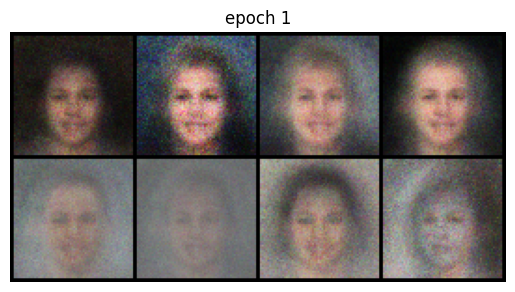

for epoch: 2/5... batch: 1... G-loss:2.59749698638916.... D-loss: 0.3853524625301361
for epoch: 2/5... batch: 51... G-loss:1.3476488590240479.... D-loss: 0.605053722858429
for epoch: 2/5... batch: 101... G-loss:2.779914140701294.... D-loss: 0.3582087755203247
for epoch: 2/5... batch: 151... G-loss:3.0478711128234863.... D-loss: 0.29240697622299194
for epoch: 2/5... batch: 201... G-loss:2.3469533920288086.... D-loss: 0.49324744939804077
for epoch: 2/5... batch: 251... G-loss:2.501910924911499.... D-loss: 0.3588971495628357
for epoch: 2/5... batch: 301... G-loss:2.5222742557525635.... D-loss: 0.4208836555480957
for epoch: 2/5... batch: 351... G-loss:2.6040916442871094.... D-loss: 0.29885393381118774
for epoch: 2/5... batch: 401... G-loss:2.7215042114257812.... D-loss: 0.3013102412223816
for epoch: 2/5... batch: 451... G-loss:2.646094799041748.... D-loss: 0.41394203901290894
for epoch: 2/5... batch: 501... G-loss:2.417508602142334.... D-loss: 0.4274020791053772
for epoch: 2/5... batch: 55

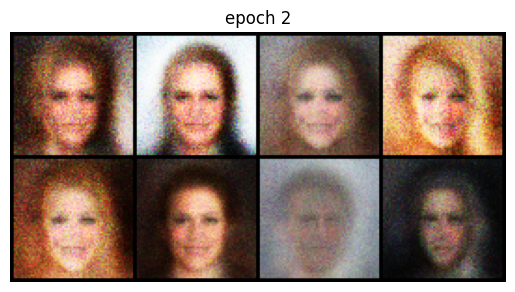

for epoch: 3/5... batch: 1... G-loss:1.2627122402191162.... D-loss: 0.9797803163528442
for epoch: 3/5... batch: 51... G-loss:2.9261484146118164.... D-loss: 0.3622920513153076
for epoch: 3/5... batch: 101... G-loss:2.979020595550537.... D-loss: 0.375686377286911
for epoch: 3/5... batch: 151... G-loss:2.1387434005737305.... D-loss: 0.41041332483291626
for epoch: 3/5... batch: 201... G-loss:2.1498546600341797.... D-loss: 0.44193923473358154
for epoch: 3/5... batch: 251... G-loss:2.0758824348449707.... D-loss: 0.4197925925254822
for epoch: 3/5... batch: 301... G-loss:1.9323481321334839.... D-loss: 0.3811562657356262
for epoch: 3/5... batch: 351... G-loss:2.0667099952697754.... D-loss: 0.6003226637840271
for epoch: 3/5... batch: 401... G-loss:2.148531436920166.... D-loss: 0.3883265256881714
for epoch: 3/5... batch: 451... G-loss:2.6706416606903076.... D-loss: 0.3592463433742523
for epoch: 3/5... batch: 501... G-loss:2.07296085357666.... D-loss: 0.36961629986763
for epoch: 3/5... batch: 551.

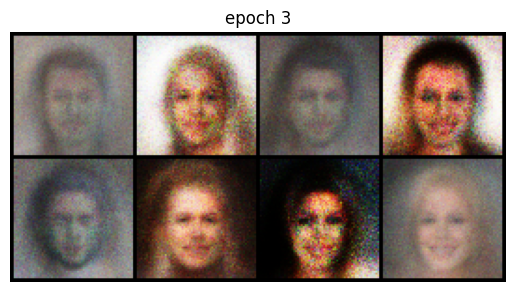

for epoch: 4/5... batch: 1... G-loss:1.7090646028518677.... D-loss: 0.44213539361953735
for epoch: 4/5... batch: 51... G-loss:1.9443620443344116.... D-loss: 0.5018730759620667
for epoch: 4/5... batch: 101... G-loss:2.283905029296875.... D-loss: 0.38419944047927856
for epoch: 4/5... batch: 151... G-loss:1.743361234664917.... D-loss: 0.4208104610443115
for epoch: 4/5... batch: 201... G-loss:1.5956239700317383.... D-loss: 0.6064838171005249
for epoch: 4/5... batch: 251... G-loss:1.676473617553711.... D-loss: 0.6000473499298096
for epoch: 4/5... batch: 301... G-loss:1.9935837984085083.... D-loss: 0.40861207246780396
for epoch: 4/5... batch: 351... G-loss:1.7529124021530151.... D-loss: 0.47543737292289734
for epoch: 4/5... batch: 401... G-loss:1.9639649391174316.... D-loss: 0.41745975613594055
for epoch: 4/5... batch: 451... G-loss:2.399390459060669.... D-loss: 0.512728214263916
for epoch: 4/5... batch: 501... G-loss:1.5172159671783447.... D-loss: 0.4361649751663208
for epoch: 4/5... batch:

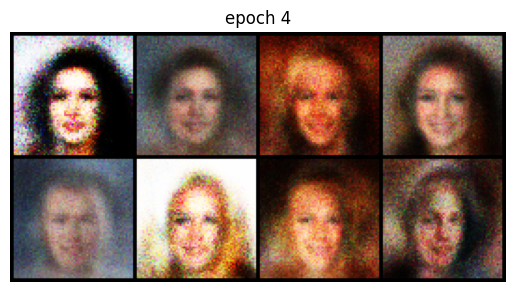

for epoch: 5/5... batch: 1... G-loss:1.7367353439331055.... D-loss: 0.5073139667510986
for epoch: 5/5... batch: 51... G-loss:2.11265230178833.... D-loss: 0.5183833837509155
for epoch: 5/5... batch: 101... G-loss:1.8785430192947388.... D-loss: 0.49157416820526123
for epoch: 5/5... batch: 151... G-loss:1.5029451847076416.... D-loss: 0.4401269257068634
for epoch: 5/5... batch: 201... G-loss:1.6432616710662842.... D-loss: 0.4587477743625641
for epoch: 5/5... batch: 251... G-loss:1.53589928150177.... D-loss: 0.5023577809333801
for epoch: 5/5... batch: 301... G-loss:1.4980372190475464.... D-loss: 0.45340558886528015
for epoch: 5/5... batch: 351... G-loss:1.2860558032989502.... D-loss: 0.5536935329437256
for epoch: 5/5... batch: 401... G-loss:1.3943976163864136.... D-loss: 0.614966869354248
for epoch: 5/5... batch: 451... G-loss:1.5961904525756836.... D-loss: 0.516281008720398
for epoch: 5/5... batch: 501... G-loss:1.4232399463653564.... D-loss: 0.5562265515327454
for epoch: 5/5... batch: 551

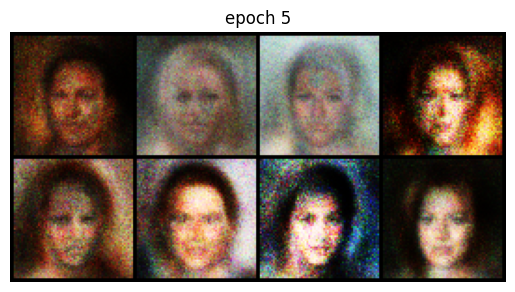

In [27]:
train(generator, discriminator, dataloader, epochs=5)